In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from numpy.random import uniform as unif

import os 
import sys

sys.path.append("./../../")
from utils import *
from utils_data import *

In [ ]:
np.random.seed(43)

n_rct = 2000
n_obs = 2000
n_rct_val = 500
n_obs_val = 500

d = 3

meas_covs = [f"X{i + 1}" for i in range(d)]
unmeas_covs = [f"U{i + 1}" for i in range(d)]

all_covs = meas_covs + unmeas_covs
adjust_covs = all_covs
# adjust_covs = meas_covs

K = 10
biases = {"avg": [], "X<0": [], "X>0": []}
covariances = {"train": {"SE_Y0": [], "SE_Y1": [], "SE_A": [], "SE_S": [], "SE_R": []},
               "val": {"SE_Y0": [], "SE_Y1": [], "SE_A": [], "SE_S": [], "SE_R": []},}


for _ in range(K):
    cov = sample_cov_matrix(2)
    px_dist = "unif"

    df_rct = init_df(n_rct, d, r=1, px_dist=px_dist, mean=[0,0], cov=cov)
    df_obs = init_df(n_obs, d, r=0, px_dist=px_dist, mean=[0,0], cov=cov)
    df_rct_val = init_df(n_rct_val, d, r=1, px_dist=px_dist, mean=[0,0], cov=cov)
    df_obs_val = init_df(n_obs_val, d, r=0, px_dist=px_dist, mean=[0,0], cov=cov)

    rct_legendre_coefs = {"Y0": unif(-1, 1, 2 * d + 1),
                        "Y1": unif(-1, 1, 2 * d + 1),
                        "A": None,
                        "S": None,} 

    obs_legendre_coefs = {"Y0": rct_legendre_coefs["Y0"],
                        "Y1": rct_legendre_coefs["Y1"],
                        "A": None,
                        "S": None,}

    random_probs = {"Y0": 0.5, "Y1": 0.5, "A": 0.5, "S": 0.95}

    # generate data and fit estimators

    sample_TOS(df_rct, all_covs, rct_legendre_coefs, random_probs)
    sample_TOS(df_obs, all_covs, obs_legendre_coefs, random_probs)
    sample_TOS(df_rct_val, all_covs, rct_legendre_coefs, random_probs)
    sample_TOS(df_obs_val, all_covs, obs_legendre_coefs, random_probs)

    rct_models = fit_all_models(df_rct, adjust_covs)
    log_model_preds(df_rct, adjust_covs, rct_models)
    log_model_preds(df_rct_val, adjust_covs, rct_models)

    
    obs_models = fit_all_models(df_obs, adjust_covs)
    log_model_preds(df_obs, adjust_covs, obs_models)
    log_model_preds(df_obs_val, adjust_covs, obs_models)

    df_merged, pr_model = merge_df(df_rct, df_obs, adjust_covs)
    df_merged_val, _ = merge_df(df_rct_val, df_obs_val, adjust_covs, pr_model=pr_model, log_psi=False)

    K1 = rbf_kernel_two_matrices(df_merged_val[adjust_covs], df_merged[adjust_covs])
    df_merged_val['w(X)'] = K1 @ df_merged['psi']

    # K2 = rbf_kernel(df_merged[adjust_covs])
    # df_merged['w(X)'] = K2 @ df_merged['psi']

    for key in covariances["train"]:
        m, p, _, _ = pearsonr_ci(df_merged_val, "w(X)", key)
        covariances["val"][key].append((m,p))

        # m, p, _, _ = pearsonr_ci(df_merged, "w(X)", key)
        # covariances["train"][key].append((m,p))

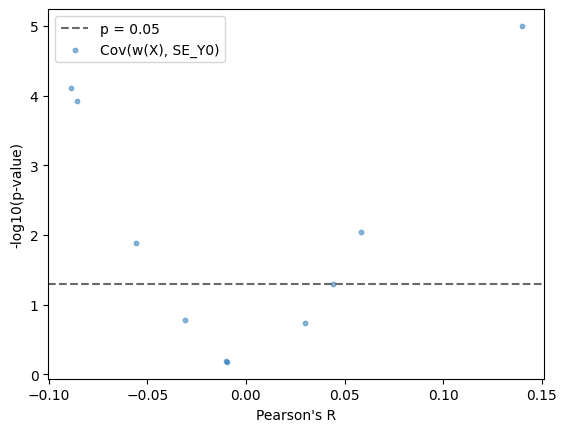

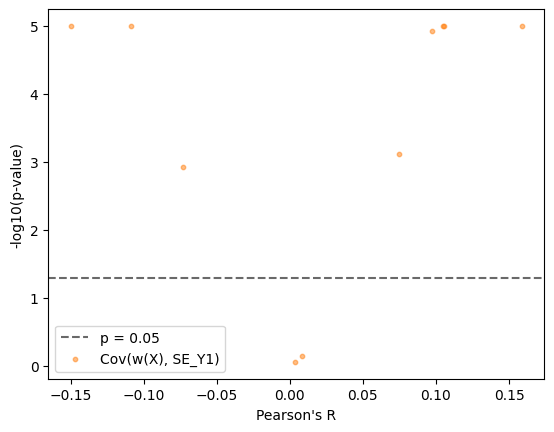

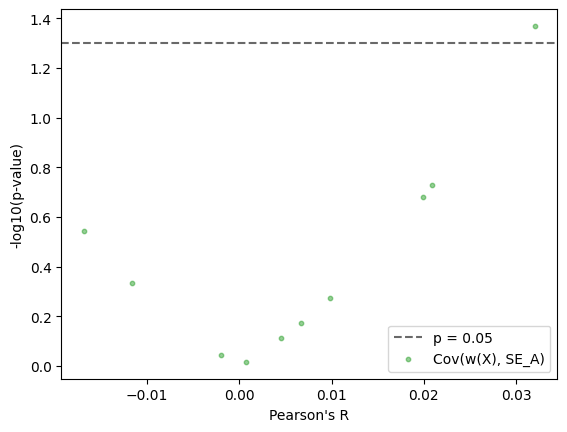

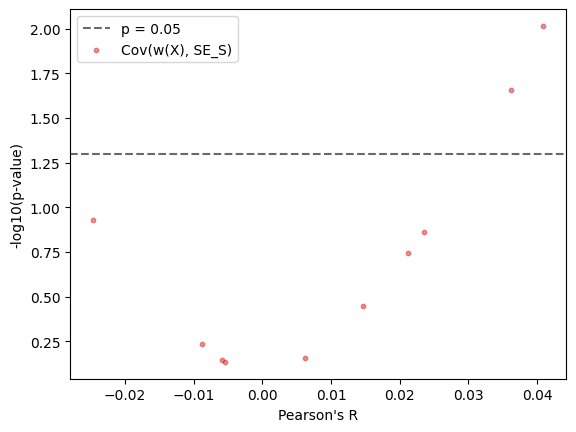

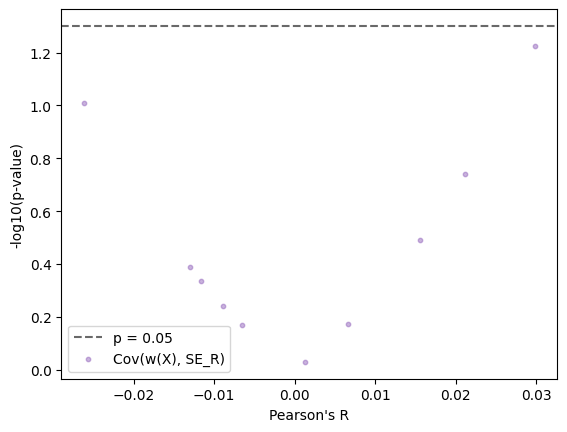

In [4]:
cp = sns.color_palette("tab10")

for i, key in enumerate(covariances["train"]):
    plt.figure()
    plt.xlabel("Pearson's R")
    plt.ylabel('-log10(p-value)')
    plt.axhline(y=-np.log10(0.05), color='dimgray', linestyle='--', label='p = 0.05')
    
    arr = np.array(covariances["val"][key])
    hat_cov = arr[:, 0]
    log_p_val = np.clip(-np.log10(arr[:, 1]), a_min=None, a_max=5)
    plt.scatter(hat_cov, log_p_val, color=cp[i], s=10, alpha=0.5, label=f"Cov(w(X), {key})")

    plt.legend()
    plt.show()

In [15]:
k = "SE_A"
(df_merged_val["w(X)"] * df_merged_val[k]).dropna().mean() - df_merged_val["w(X)"].mean()* df_merged_val[k].dropna().mean()

0.001236247014448466

In [21]:
df_merged_val[["A", "Y", "mu_0", "mu_1", "SE_Y0", "SE_Y1", "w(X)"]].sort_values(by="SE_Y1", ascending=False).iloc[:50,:]

,A,Y,mu_0,mu_1,SE_Y0,SE_Y1,w(X)
3957,1,0,0.135408,0.891472,NaN,0.794722,-7.333408
3386,1,0,0.328322,0.881116,NaN,0.776366,-5.667734
3787,1,0,0.162277,0.873368,NaN,0.762771,-4.087059
3232,1,0,0.167116,0.857735,NaN,0.735710,-17.812634
1658,1,0,0.159540,0.856480,NaN,0.733559,-5.176974
3305,1,0,0.154932,0.856209,NaN,0.733094,-5.367106
1739,1,0,0.165623,0.854397,NaN,0.729995,-4.642829
1457,1,0,0.147297,0.850861,NaN,0.723965,-8.437960
3597,1,0,0.141765,0.844126,NaN,0.712548,-12.873829
2973,1,0,0.158225,0.843916,NaN,0.712194,-5.687383


In [ ]:
cp = sns.color_palette("tab10")

for i, key in enumerate(covariances["train"]):
    plt.figure()
    plt.xlabel("Pearson's R")
    plt.ylabel('-log10(p-value)')
    plt.axhline(y=-np.log10(0.05), color='dimgray', linestyle='--', label='p = 0.05')
    
    arr = np.array(covariances["val"][key])
    hat_cov = arr[:, 0]
    log_p_val = np.clip(-np.log10(arr[:, 1]), a_min=None, a_max=5)
    plt.scatter(hat_cov, log_p_val, color=cp[i], s=10, alpha=0.5, label=f"Cov(w(X), {key})")

    plt.legend()
    plt.show()

In [ ]:
rct_models["Y1"].coef_ = np.array([[1,2,3,4,5,6]])

In [ ]:
rct_legendre_coefs["Y0"][1:].reshape(1,-1).shape

In [ ]:
rct_models["Y1"].intercept_

In [ ]:
obs_models["Y1"].coef_

In [ ]:
obs_models["Y1"].intercept_

In [ ]:
df_merged